In [1]:
#importing required libraries
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, AveragePooling2D, BatchNormalization, Dropout
from keras.preprocessing.image import ImageDataGenerator

c:\Python310\lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import tensorflow as tf
print("Device:", tf.test.gpu_device_name())


Device: 


In [3]:
# Setting the path to our data
train_data_dir = './Ultra_weld_dataset/train/'
validation_data_dir = './Ultra_weld_dataset/valid/'
test_data_dir = "./Ultra_weld_dataset/test/"

In [4]:
# Setting the image and batch size
img_width, img_height = 224, 224
batch_size = 10

In [6]:

# Data augmentation for training set
train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

# Only rescaling for validation set
val_datagen = ImageDataGenerator(rescale=1./255)

# Only rescaling for testing set
test_datagen = ImageDataGenerator(rescale=1./255)

# Load and preprocess the training and validation datasets
train_generator = train_datagen.flow_from_directory(train_data_dir,
                                                    target_size=(img_width, img_height),
                                                    batch_size=batch_size,
                                                    class_mode='categorical')

validation_generator = val_datagen.flow_from_directory(validation_data_dir,
                                                      target_size=(img_width, img_height),
                                                      batch_size=batch_size,
                                                      class_mode='categorical')

test_generator = test_datagen.flow_from_directory(test_data_dir,
                                                      target_size=(img_width, img_height),
                                                      batch_size=batch_size,
                                                      class_mode='categorical')



Found 420 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
Found 80 images belonging to 4 classes.


In [31]:
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     min_delta=0.001,
#     patience=20,
#     restore_best_weights=True,
# )

In [7]:
# Create the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3))) 
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
# conv1_output = model.layers[-1].output
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
# model.add(Dropout(0.3))
# model.add(BatchNormalization())
model.add(Dense(4, activation='softmax'))


In [8]:
# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

In [10]:
# model fitting
epochs = 10
steps_per_epoch = train_generator.n / batch_size
validation_steps = validation_generator.n / batch_size

history = model.fit(train_generator,steps_per_epoch=steps_per_epoch,epochs=epochs,validation_data=validation_generator)
# callbacks=[early_stopping]

Epoch 1/10


42/42 [==============================] - 35s 784ms/step - loss: 1.6811 - accuracy: 0.3071 - val_loss: 1.3273 - val_accuracy: 0.3700
Epoch 2/10
42/42 [==============================] - 44s 1s/step - loss: 1.0854 - accuracy: 0.5190 - val_loss: 0.7567 - val_accuracy: 0.7800
Epoch 3/10
42/42 [==============================] - 29s 699ms/step - loss: 0.5036 - accuracy: 0.8333 - val_loss: 0.4955 - val_accuracy: 0.8800
Epoch 4/10
42/42 [==============================] - 49s 1s/step - loss: 0.2959 - accuracy: 0.9048 - val_loss: 0.2693 - val_accuracy: 0.9400
Epoch 5/10
42/42 [==============================] - 146s 3s/step - loss: 0.3672 - accuracy: 0.8881 - val_loss: 0.2267 - val_accuracy: 0.9600
Epoch 6/10
42/42 [==============================] - 141s 3s/step - loss: 0.2730 - accuracy: 0.9119 - val_loss: 0.2571 - val_accuracy: 0.9200
Epoch 7/10
42/42 [==============================] - 163s 4s/step - loss: 0.1802 - accuracy: 0.9333 - val_loss: 0.6849 - val_accuracy: 0.8900
Epoch 8/1

In [11]:
# Evaluate the model on the testing set
test_loss, test_acc  = model.evaluate(test_generator)
print(f'Test_accuracy:{test_acc}')
print(f'Test_loss:{test_loss}')

# Make predictions on the test set / predections gives us the categoury/ class for which our data/ image belongs to/ givest he classification probabilitiees
predictions = model.predict(test_generator)

8/8 [==============================] - 6s 684ms/step - loss: 0.0300 - accuracy: 0.9875
Test_accuracy:0.987500011920929
Test_loss:0.030016478151082993
8/8 [==============================] - 6s 656ms/step


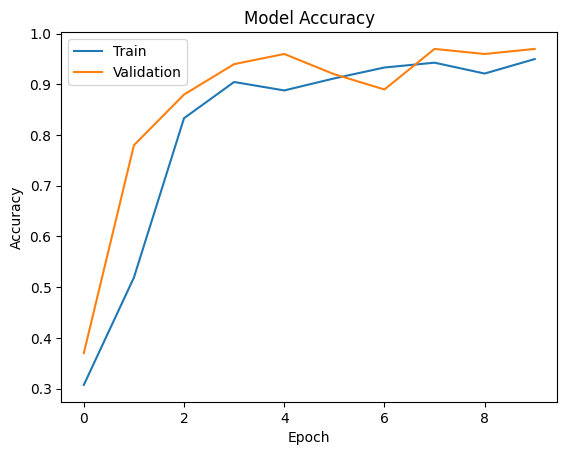

In [12]:
# Plot the training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [1]:
# #saving model
# from keras.models import load_model

# # Save the model
# model.save('Ultrasonic_welding_IPDL.h5')

# # # Load the model
# model1 = load_model('./Ultrasonic_welding_IPDL.h5')


In [2]:
# #predection on random images
# from PIL import Image
# import os

# # Define the classes
# classes = ['dent', 'good', 'overextrusion', 'scratch']

# # Set the path to the image dataset
# image_path = './test_predect/'

# # Loop through the images in the dataset
# for file in os.listdir(image_path):
#     # Load the image
#     img = Image.open(os.path.join(image_path, file)).resize((224, 224))
#     img = np.array(img) / 255.0
#     img = np.expand_dims(img, axis=0)
    
#     # Make a prediction
#     prediction = model1.predict(img)

    
#     # Get the label of the predicted class
#     label = classes[np.argmax(prediction)]
    
#     # Print the prediction along with the label
#     print(f"Prediction: {prediction}, Label: {label}")

In [3]:
# import os
# from PIL import Image
# from sklearn.metrics import confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Define the classes
# classes = ['dent', 'good', 'overextrusion', 'scratch']

# # Set the path to the image dataset
# image_path = './test_predect/'

# # Initialize an empty list to store predictions and true labels
# all_predictions = []
# all_true_labels = []

# # Loop through the images in the dataset
# for file in os.listdir(image_path):
#     # Load the image
#     img = Image.open(os.path.join(image_path, file)).resize((224, 224))
#     img = np.array(img) / 255.0
#     img = np.expand_dims(img, axis=0)
    
#     # Make a prediction
#     prediction = model1.predict(img)
    
#     # Get the label of the predicted class
#     predicted_label = classes[np.argmax(prediction)]
    
#     # Extract the true label from the filename (modify the parsing if needed)
#     true_label = file.split('_')[0].lower()  # Assuming the filename contains the true label before an underscore
    
#     # Check if the true label is valid (exists in classes)
#     if true_label not in classes:
#         print(f"Warning: Invalid true label '{true_label}' for file '{file}'. Skipping this sample.")
#     else:
#         # Add predictions and true labels to the lists
#         all_predictions.append(predicted_label)
#         all_true_labels.append(true_label)

#         # Print the prediction along with the label
#         print(f"{file} - Prediction: {predicted_label}, True Label: {true_label}")

# # Create the confusion matrix if there are valid samples
# if len(all_predictions) > 0:
#     # Create the confusion matrix
#     conf_matrix = confusion_matrix(all_true_labels, all_predictions, labels=classes)

#     # Plot the confusion matrix
#     plt.figure(figsize=(8, 6))
#     sns.heatmap(conf_matrix, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
#     plt.xlabel('Predicted Labels')
#     plt.ylabel('True Labels')
#     plt.title('Confusion Matrix')
#     plt.show()
# else:
#     print("No valid samples found. Check the true labels and filenames.")
